# Business Challenge I MBANDD 20th of December

Group 6: Group 6: Aditya Arte, Ken Yu Chua, Jayanth Kodali, Antonia Scabell, Utamaru Sogawa and Katarina Ronbeck.

## Importing Data from SQL

In [603]:
!pip install mysql-connector-python # Note, we only run this line one time.
import mysql.connector
from mysql.connector import Error

In [604]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

### Transposing and Cleaning Data for Analysis

In [608]:
# Creating a new dataframe with transposed values.
ticker_price_transposed = ticker_price.drop(columns=['index'])
ticker_price_transposed = ticker_price_transposed.pivot(index='date', columns='ticker', values='adj_closing_price')
ticker_price_transposed = ticker_price_transposed.reset_index()

ticker_price_transposed['date'] = pd.to_datetime(ticker_price_transposed['date'])
print(ticker_price_transposed)

ticker       date     ACN    ADBE    ADSK    AGG    ALGN    APH    ARGX  \
0      2014-12-16   70.25   72.32   56.63  85.04   55.08  11.72     NaN   
1      2014-12-17   72.31   74.00   57.01  84.93   55.45  11.95     NaN   
2      2014-12-18   76.08   74.89   59.46  84.71   56.10  12.35     NaN   
3      2014-12-19   76.73   74.45   59.90  84.85   56.83  12.49     NaN   
4      2014-12-22   77.30   74.50   60.19  84.98   56.88  12.54     NaN   
...           ...     ...     ...     ...    ...     ...    ...     ...   
2511   2024-12-09  359.50  547.93  308.55  98.72  237.57  73.51  611.01   
2512   2024-12-10  362.90  547.05  303.99  98.60  237.16  72.45  609.88   
2513   2024-12-11  363.84  549.93  307.46  98.37  239.52  73.37  605.87   
2514   2024-12-12  360.18  474.63  309.34  97.97  235.72  73.44  603.40   
2515   2024-12-13  358.68  465.69  303.77  97.60  235.39  73.47  607.21   

ticker    AVGO     BKNG  ...    TEAM     TIP    TLT     TRU    TSLA     TSM  \
0         7.41  1036

## Rate of Returns

We start by creating a dataframe for ROR for all securities.

In [609]:
# Creating a new dataframe with ROR of the tickers.

ror_df = pd.DataFrame(ticker_price_transposed.copy())
ror_df.iloc[:,1:] = ticker_price_transposed.iloc[:, 1:].pct_change(1) * 100
ror_df = ror_df.drop(['BND', 'TLT', 'AGG', 'LQD', 'VCIT', 'TIP', 'NDX'], axis = 1)

# Turning NaN's to 0.
ror_df = ror_df.fillna(0)
ror_df

# Turning everything to float except date.
ror_df = ror_df.astype({col:float for col in ror_df.columns[1:]})
ror_df.info()


<ipython-input-609-0f9f8b0640aa>:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ror_df.iloc[:,1:] = ticker_price_transposed.iloc[:, 1:].pct_change(1) * 100


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2516 entries, 0 to 2515
Data columns (total 51 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2516 non-null   datetime64[ns]
 1   ACN     2516 non-null   float64       
 2   ADBE    2516 non-null   float64       
 3   ADSK    2516 non-null   float64       
 4   ALGN    2516 non-null   float64       
 5   APH     2516 non-null   float64       
 6   ARGX    2516 non-null   float64       
 7   AVGO    2516 non-null   float64       
 8   BKNG    2516 non-null   float64       
 9   BSX     2516 non-null   float64       
 10  C       2516 non-null   float64       
 11  CDNS    2516 non-null   float64       
 12  CHTR    2516 non-null   float64       
 13  CLX     2516 non-null   float64       
 14  CMG     2516 non-null   float64       
 15  COF     2516 non-null   float64       
 16  DASH    2516 non-null   float64       
 17  EQIX    2516 non-null   float64       
 18  ETN     

We now create a dataframe for the ROR of the benchmark.

In [610]:
# Creating a dataframe just for the benchmark.
ndx_df = ror_ndx = pd.DataFrame(ticker_price_transposed[['date', 'NDX']])
ndx_df = ndx_df.fillna(0)

ror_ndx = pd.DataFrame(ticker_price_transposed[['date', 'NDX']])
ror_ndx.iloc[:,1:] = ror_ndx.iloc[:, 1:].pct_change(1) * 100

# Removing NaN's and replacing them with 0.

ror_ndx = ror_ndx.fillna(0)
ror_ndx

# Making the values float.
ror_ndx = ror_ndx.astype({col:float for col in ror_ndx.columns[1:]})
ror_ndx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2516 entries, 0 to 2515
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2516 non-null   datetime64[ns]
 1   NDX     2516 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 39.4 KB


<ipython-input-610-9242e3165df4>:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ror_ndx.iloc[:,1:] = ror_ndx.iloc[:, 1:].pct_change(1) * 100


We find the average return for the original portfolio.

In [611]:
# Average return for the original portfolio.
avg_ror = pd.DataFrame(ror_df.drop(columns = ['date']).mean())
avg_ror = avg_ror.drop(avg_ror.index[0])
avg_ror.columns = ['avg_ror_perc']
avg_ror

,avg_ror_perc
ticker,
ADBE,0.095993
ADSK,0.093033
ALGN,0.101158
APH,0.084534
ARGX,0.168512
AVGO,0.162907
BKNG,0.084729
BSX,0.091104
C,0.045001


We find the standard deviation for all securities of the original portfolio.

In [612]:
# Finding the standard deviation for all secruities of the original portfolio.

std_ror = pd.DataFrame(ror_df.iloc[:, 1:].std())
std_ror_df = std_ror.reset_index()
std_ror_df.columns = ['ticker', 'std']
std_ror_df

,ticker,std
0,ACN,1.563404
1,ADBE,2.088665
2,ADSK,2.290857
3,ALGN,2.945877
4,APH,1.515647
5,ARGX,2.937315
6,AVGO,2.337890
7,BKNG,2.018314
8,BSX,1.670716
9,C,2.064220


## Portfolio Weights and Return

We start by finding Ken Griffins Assets Under Management.

In [613]:
# Finding Ken Griffin's AUM and the weight of each security in the portfolio.

aum = (trade['trade_price'] * trade['quantity']).groupby(trade['ticker']).sum()/1000000

weights_og = pd.DataFrame(aum/aum.sum())
weights_og


,0
ticker,
ACN,0.014720
ADBE,0.023137
ADSK,0.012170
ALGN,0.015805
APH,0.007257
ARGX,0.016121
AVGO,-0.001347
BKNG,0.007981
BSX,0.022146


Using the weights and the avg ror, we now find the portfolio return.

In [614]:
# Finding portfolio return using weights and ror_df based on ticker.

portfolio_return = weights_og[0]*avg_ror['avg_ror_perc']

# AVG portfolio return annually.
total_portfolio_ror = portfolio_return.sum()*255
total_portfolio_ror


19.07175001599921

We create the covariance matrix for calculating the protfolio standard deviation later.

In [615]:
# Finding coveriance matrix.

cov = pd.DataFrame(ror_df.iloc[:,1:].cov())
cov.reset_index(inplace=True)
cov

ticker,ticker,ACN,ADBE,ADSK,ALGN,APH,ARGX,AVGO,BKNG,BSX,...,SPOT,SPY,T,TEAM,TRU,TSLA,TSM,TT,UHS,VOO
0,ACN,2.444231,1.902575,2.003954,1.964860,1.485630,0.854939,1.800846,1.460033,1.324744,...,1.261973,1.329810,0.850054,1.746999,1.657437,1.801117,1.340919,1.351027,1.404708,1.340270
1,ADBE,1.902575,4.362523,3.004115,2.526932,1.638694,1.375709,2.457169,1.684106,1.445802,...,2.032028,1.589705,0.568395,3.120118,1.929248,2.898256,1.982929,1.343812,1.279837,1.605139
2,ADSK,2.003954,3.004115,5.248028,3.165119,1.999997,1.323396,2.653833,2.183528,1.635105,...,2.163925,1.724493,0.821958,3.364015,2.242029,3.067087,2.183044,1.751826,1.644502,1.735265
3,ALGN,1.964860,2.526932,3.165119,8.678190,2.152943,1.363293,2.751608,2.450364,2.048863,...,2.203410,1.845547,0.972737,3.186496,2.549969,3.399723,2.264179,1.950854,2.059856,1.861969
4,APH,1.485630,1.638694,1.999997,2.152943,2.297184,0.886205,2.178918,1.659722,1.305209,...,1.195911,1.341261,0.724403,1.541624,1.668045,2.056441,1.757884,1.618457,1.479845,1.352092
5,ARGX,0.854939,1.375709,1.323396,1.363293,0.886205,8.627822,1.240911,0.992189,0.850343,...,1.473867,0.821850,0.383707,1.683104,1.121335,1.769951,1.081188,0.818846,0.839772,0.831625
6,AVGO,1.800846,2.457169,2.653833,2.751608,2.178918,1.240911,5.465729,1.968349,1.506230,...,1.753629,1.701805,0.628086,2.092434,1.915565,3.340559,2.766930,1.670004,1.811829,1.717034
7,BKNG,1.460033,1.684106,2.183528,2.450364,1.659722,0.992189,1.968349,4.073590,1.539071,...,1.364360,1.400170,0.840452,1.876106,1.842118,2.145764,1.718035,1.588993,1.549116,1.412533
8,BSX,1.324744,1.445802,1.635105,2.048863,1.305209,0.850343,1.506230,1.539071,2.791291,...,0.823377,1.159608,0.768836,1.341558,1.482432,1.493277,1.140295,1.341924,1.736497,1.171408
9,C,1.701101,1.566818,2.098333,2.371694,1.816717,0.956791,2.047524,2.156772,1.547383,...,1.214828,1.634709,1.319789,1.207424,1.919680,2.147045,1.592228,1.830570,2.172759,1.650329


Now we can find the portfolio standard deviation, using the original weights of the portfolio and using the average rate of return of the portfolio.

In [616]:
# Finding portfolio standard deviations using weights, covariances and avg_ror.

# Merging the ror and std dataframes.
ror_weight = pd.merge(std_ror, weights_og, on='ticker', how='inner')
ror_weight.rename(columns={"0_x": "ror", "0_y": "weight"}, inplace=True)
ror_weight.reset_index(inplace=True)
ror_weight

# Table for calculation.
ror_weight['weight_squared'] = ror_weight['weight']**2
ror_weight['ror_squared'] = ror_weight['ror']**2
ror_weight['ror_weight_squared'] = ror_weight['ror_squared']*ror_weight['weight_squared']

# Finding the transposed weights.
weights_t = weights_og.transpose()

# Finding the weighted covariance.
covariance_maths = np.dot(np.dot(weights_t, cov.iloc[:, 1:]), weights_og)
weighted_covariance = 2*covariance_maths[0]

# Portfolio_variance
portfolio_variance = weighted_covariance + ror_weight['ror_weight_squared'].sum()

# Portfolio_standard_deviation
portfolio_standard_deviation = portfolio_variance**0.5

# Annualize the findings.
annual_portfolio_std = portfolio_standard_deviation*np.sqrt(255)
annual_portfolio_var = portfolio_variance*255

print(portfolio_standard_deviation)
print(covariance_maths)
print(portfolio_variance)
print(annual_portfolio_std)
print(annual_portfolio_var)

[1.71144198]
[[1.39767263]]
[2.92903365]
[27.32953677]
[746.90358024]


We can now find the original portfolio's Sharpe Ratio using the 30-year US Treasury Yield as the risk-free rate.

In [617]:
# Finding the original portfolio's Sharpe Ratio.

rf = 4.6150
sharpe_ratio_og = (total_portfolio_ror - rf)/annual_portfolio_std
sharpe_ratio_og

# Source for rf for the 13th of December: https://finance.yahoo.com/quote/%5ETYX/history/.

array([0.52897896])

## Vizualisation of ROR

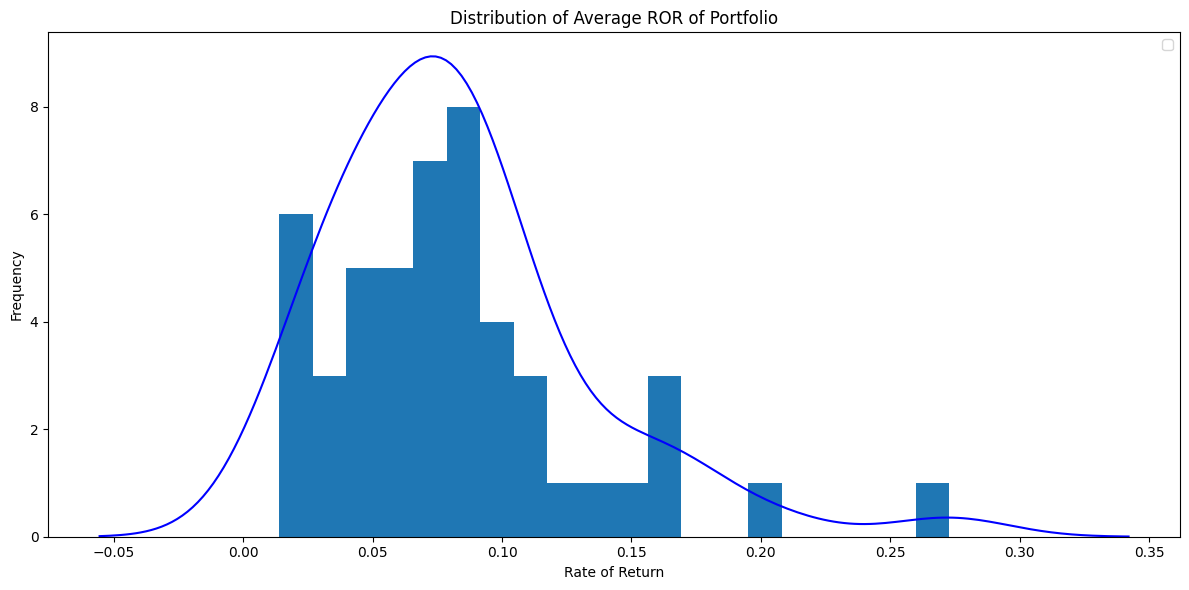

In [618]:
## Create histogram to show ROR distribution for whole portfolio

plt.figure(figsize=(12, 6))
plt.hist(avg_ror, bins=20)
sns.kdeplot(avg_ror.values.flatten(), color='blue')

# Add labels, title, and legend
plt.xlabel('Rate of Return')
plt.ylabel('Frequency')
plt.title('Distribution of Average ROR of Portfolio')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Looking at the histogram of the average rate of returns of the securities in the original portfolio, we see a right skewed distribution. We also see most observation between 5-10% of average rate of returns, which is good.

## Random Weights and Portfolio Optimization with Diversification

We start by creating a new dataframe to use in finding a diversified portfolio.

In [619]:
ror_df_div = pd.DataFrame(ticker_price_transposed.copy())
ror_df_div.iloc[:,1:] = ticker_price_transposed.iloc[:, 1:].pct_change(1) * 100

# Turning NaN's to 0.
ror_df_div = ror_df_div.fillna(0)
ror_df_div

# Turning everything to float except date.
ror_df_div = ror_df_div.astype({col:float for col in ror_df_div.columns[1:]})
ror_df_div.info()

<ipython-input-619-f29623add9bd>:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ror_df_div.iloc[:,1:] = ticker_price_transposed.iloc[:, 1:].pct_change(1) * 100


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2516 entries, 0 to 2515
Data columns (total 58 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2516 non-null   datetime64[ns]
 1   ACN     2516 non-null   float64       
 2   ADBE    2516 non-null   float64       
 3   ADSK    2516 non-null   float64       
 4   AGG     2516 non-null   float64       
 5   ALGN    2516 non-null   float64       
 6   APH     2516 non-null   float64       
 7   ARGX    2516 non-null   float64       
 8   AVGO    2516 non-null   float64       
 9   BKNG    2516 non-null   float64       
 10  BND     2516 non-null   float64       
 11  BSX     2516 non-null   float64       
 12  C       2516 non-null   float64       
 13  CDNS    2516 non-null   float64       
 14  CHTR    2516 non-null   float64       
 15  CLX     2516 non-null   float64       
 16  CMG     2516 non-null   float64       
 17  COF     2516 non-null   float64       
 18  DASH    

We find the average return of the diverisfied portfolio.

In [620]:
# Average return diversified portfolio.
avg_ror_div = pd.DataFrame(ror_df_div.mean())
avg_ror_div = avg_ror_div.drop(avg_ror_div.index[0])
avg_ror_div.columns = ['ror']
avg_ror_div

,ror
ticker,
ACN,0.077024
ADBE,0.095993
ADSK,0.093033
AGG,0.006035
ALGN,0.101158
APH,0.084534
ARGX,0.168512
AVGO,0.162907
BKNG,0.084729


We then find the standard deviation for all the secruities included in this diversified portfolio.

In [621]:
# Finding the standard deviation for all secruities.

std_ror_div = pd.DataFrame(ror_df_div.iloc[:, 1:].std())
std_df_div = std_ror_div.reset_index()
std_df_div.columns = ['ticker', 'std']
std_df_div

,ticker,std
0,ACN,1.563404
1,ADBE,2.088665
2,ADSK,2.290857
3,AGG,0.334115
4,ALGN,2.945877
5,APH,1.515647
6,ARGX,2.937315
7,AVGO,2.337890
8,BKNG,2.018314
9,BND,0.342661


We make sure we have a new covariance matrix, as there are now additional securities in the portfolio.

In [622]:
# Creating the diversified covariance matrix.
cov_div = pd.DataFrame(ror_df_div.iloc[:,1:].cov())
cov_div.reset_index(inplace=True)
cov_div

ticker,ticker,ACN,ADBE,ADSK,AGG,ALGN,APH,ARGX,AVGO,BKNG,...,TEAM,TIP,TLT,TRU,TSLA,TSM,TT,UHS,VCIT,VOO
0,ACN,2.444231,1.902575,2.003954,0.048268,1.964860,1.485630,0.854939,1.800846,1.460033,...,1.746999,0.013121,-0.205752,1.657437,1.801117,1.340919,1.351027,1.404708,0.104057,1.340270
1,ADBE,1.902575,4.362523,3.004115,0.074048,2.526932,1.638694,1.375709,2.457169,1.684106,...,3.120118,0.031002,-0.163481,1.929248,2.898256,1.982929,1.343812,1.279837,0.157519,1.605139
2,ADSK,2.003954,3.004115,5.248028,0.098210,3.165119,1.999997,1.323396,2.653833,2.183528,...,3.364015,0.044783,-0.201106,2.242029,3.067087,2.183044,1.751826,1.644502,0.183098,1.735265
3,AGG,0.048268,0.074048,0.098210,0.111633,0.117834,0.034076,0.069567,0.056464,0.022213,...,0.120915,0.093441,0.268007,0.107189,0.104553,0.034792,0.051859,0.075074,0.114309,0.032551
4,ALGN,1.964860,2.526932,3.165119,0.117834,8.678190,2.152943,1.363293,2.751608,2.450364,...,3.186496,0.063248,-0.163086,2.549969,3.399723,2.264179,1.950854,2.059856,0.239377,1.861969
5,APH,1.485630,1.638694,1.999997,0.034076,2.152943,2.297184,0.886205,2.178918,1.659722,...,1.541624,0.022063,-0.247398,1.668045,2.056441,1.757884,1.618457,1.479845,0.105414,1.352092
6,ARGX,0.854939,1.375709,1.323396,0.069567,1.363293,0.886205,8.627822,1.240911,0.992189,...,1.683104,0.031887,-0.055112,1.121335,1.769951,1.081188,0.818846,0.839772,0.116221,0.831625
7,AVGO,1.800846,2.457169,2.653833,0.056464,2.751608,2.178918,1.240911,5.465729,1.968349,...,2.092434,0.034751,-0.275892,1.915565,3.340559,2.766930,1.670004,1.811829,0.120659,1.717034
8,BKNG,1.460033,1.684106,2.183528,0.022213,2.450364,1.659722,0.992189,1.968349,4.073590,...,1.876106,-0.011322,-0.348508,1.842118,2.145764,1.718035,1.588993,1.549116,0.112830,1.412533
9,BND,0.048323,0.088025,0.098626,0.109432,0.116983,0.040617,0.076393,0.043602,0.029688,...,0.116594,0.093224,0.262865,0.103670,0.065938,0.035804,0.052337,0.047721,0.117072,0.039940


Now, since we have new additional securities, we create random weights for this new portfolio with the new securities.

In [623]:
# Creating random weights for the stocks.
import random

def generate_portfolio_weights(n):
  weights = []
  for i in range(n):
    weights.append(random.random())
  weights = weights/np.sum(weights)
  return weights

# Source: CFA.

In [624]:
weights = generate_portfolio_weights(57)
weights = pd.DataFrame([0.0160726 , 0.03429453, 0.03042467, 0.02578904, 0.00415212,
       0.00952137, 0.00574119, 0.03076728, 0.01631181, 0.00785968,
       0.00571784, 0.01378133, 0.03548848, 0.03101835, 0.0105956 ,
       0.02475666, 0.03155581, 0.03449102, 0.00528938, 0.02155659,
       0.01761444, 0.03105152, 0.01338311, 0.01533741, 0.01107309,
       0.00544102, 0.01065184, 0.02314701, 0.02815886, 0.02403945,
       0.01313321, 0.02458066, 0.00411958, 0.00681218, 0.02127371,
       0.02881771, 0.01393038, 0.01127579, 0.02347825, 0.02911349,
       0.01391196, 0.01406695, 0.018288  , 0.00241332, 0.02103338,
       0.00127942, 0.02844684, 0.02694031, 0.00559148, 0.02471612,
       0.0030819 , 0.01788596, 0.02082968, 0.02446037, 0.01029117,
       0.00957985, 0.00556522])

We then match the new random weights to the securities, and merge this dataframe with the ticker diversification dataframe.

In [625]:
# Match the new weights randomly to the ticker.

ticker_div = pd.DataFrame(['ACN', 'ADBE', 'ADSK', 'AGG', 'ALGN', 'APH', 'ARGX', 'AVGO',
       'BKNG', 'BND', 'BSX', 'C', 'CDNS', 'CHTR', 'CLX', 'CMG', 'COF', 'DASH',
       'EQIX', 'ETN', 'FIS', 'GEHC', 'GILD', 'GS', 'HD', 'HES', 'HLT', 'INTC',
       'ISRG', 'KDP', 'KO', 'LQD', 'MA', 'MAR', 'MDT', 'MMM', 'MRK', 'MSFT',
       'NDX', 'NTRA', 'NVDA', 'PM', 'PNC', 'SHW', 'SPOT', 'SPY', 'T', 'TEAM',
       'TIP', 'TLT', 'TRU', 'TSLA', 'TSM', 'TT', 'UHS', 'VCIT', 'VOO'])


# Merging the random weights and the ticker_div dataframe.

weights_div_merged = pd.concat([ticker_div, weights], axis = 1)
weights_div_merged.columns = ['ticker', 'weights']

# Merging the avg_ror_div.

weights_div_merged_t = pd.merge(weights_div_merged, avg_ror_div, on = 'ticker')
weights_div_merged_t


,ticker,weights,ror
0,ACN,0.016073,0.077024
1,ADBE,0.034295,0.095993
2,ADSK,0.030425,0.093033
3,AGG,0.025789,0.006035
4,ALGN,0.004152,0.101158
5,APH,0.009521,0.084534
6,ARGX,0.005741,0.168512
7,AVGO,0.030767,0.162907
8,BKNG,0.016312,0.084729
9,BND,0.007860,0.006321


Now we can find the diversified portfolio's average annual rate of return.

In [626]:
# Finding the diversified portfolio's average annual rate of return.

# Finding portfolio return using weights and ror_df based on ticker.

portfolio_return_div = weights_div_merged_t['weights']*weights_div_merged_t['ror']

# AVG portfolio return annually.
total_portfolio_return_div = portfolio_return_div.sum()*255
print(total_portfolio_return_div)


18.996268932009375


We use the same process as before to find the portfolio standard deviation.

In [627]:
# Finding diversified portfolio standard deviations using weights, covariances and avg_ror.

# Merging the weights_div_merged_t and std dataframes.
ror_div_weight = pd.merge(std_df_div, weights_div_merged_t, on='ticker', how='inner')
ror_div_weight.reset_index(inplace=True)
ror_div_weight

# Table for calculation.
ror_div_weight['weight_squared'] = ror_div_weight['weights']**2
ror_div_weight['ror_squared'] = ror_div_weight['ror']**2
ror_div_weight['ror_weight_squared'] = ror_div_weight['ror_squared']*ror_div_weight['weight_squared']


# Finding the transposed weights.
weights_div_t = weights.transpose()

# Finding the weighted covariance.
covariance_maths_div = np.dot(np.dot(weights_div_t, cov_div.iloc[:, 1:]), weights)
weighted_covariance_div = 2*covariance_maths_div[0]

# Portfolio_variance
portfolio_variance_div = weighted_covariance_div + ror_div_weight['ror_weight_squared'].sum()

# Portfolio_standard_deviation
portfolio_standard_deviation_div = portfolio_variance_div**0.5

# Annualize the findings.
annual_portfolio_std_div = portfolio_standard_deviation_div*np.sqrt(255)
annual_portfolio_var_div = portfolio_variance_div*255

print(portfolio_standard_deviation_div)
print(covariance_maths_div)
print(portfolio_variance_div)
print(annual_portfolio_std_div)
print(annual_portfolio_var_div)

[1.51922853]
[[1.15393003]]
[2.30805531]
[24.26013406]
[588.55410479]


And finally, finding the new Sharpe Ratio for the new diversified portfolio.

In [628]:
# Finding the original portfolio's Sharpe Ratio.
sharpe_ratio_div = (total_portfolio_return_div - rf)/annual_portfolio_std_div
sharpe_ratio_div

array([0.59279429])

We see that we have managed to:

* Increase Sharpe Ratio from 0.5289 in the original portfolio to 0.5927 for the new diversified portfolio.
* Reduced the standard deviation of the portfolio from 27.3295% in the original to 24.2601% in the diversified portfolio.
* Reduced the average annual rate of return for the portfolio from 19.0717% in the original to 18.9962% in the diversified portfolio. However, this reduction is lower than the reduction of risk, and therefore we see a higher Sharpe Ratio.

## Normalizing Prices for Visualization Purposes

In [629]:
ticker_price_normalized = ticker_price_transposed.copy()
ticker_price_normalized_filtered = ticker_price_normalized[ticker_price_normalized['date']>= '2018-01-01']

ticker_price_normalized_filtered.iloc[:,1:] = 100*(ticker_price_normalized_filtered.iloc[:,1:] / ticker_price_normalized_filtered.iloc[0, :])
ticker_price_normalized

filtered_final = ticker_price_normalized_filtered[ticker_price_normalized_filtered['date']>='2018-01-01']
filtered_final

# Source: https://stackoverflow.com/questions/61128874/python-timeseries-normalize-scaling-to-base-100 and CFA.

ticker,date,ACN,ADBE,ADSK,AGG,ALGN,APH,ARGX,AVGO,BKNG,...,TEAM,TIP,TLT,TRU,TSLA,TSM,TT,UHS,VCIT,VOO
766,2018-01-02,100,100,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,100
767,2018-01-03,100.4615606519544208856195009,101.8795723128868880135059088,102.1097834204630321135175504,100,102.9293918618110586768765025,101.3170731707317073170731707,97.92941176470588235294117647,101.0757717492984097287184284,102.2085175177778029009756594,...,107.0973225669358266043348916,100.0980712651193200392285060,100.4759638267491670633031890,99.77443609022556390977443609,98.97051941974730931211979410,101.6855565242662016855565243,101.3636363636363636363636364,98.08979737570293671338034455,100.0725478816018572257690075,100.5941851499070168276863065
768,2018-01-04,101.6515217077744122313572768,103.1063590320765334833989871,104.6209858103061986557132188,99.94472695113862480654432899,103.8643041581337369780073012,100.9268292682926829268292683,93.78823529411764705882352941,101.1225444340505144995322732,101.2611217256622160921619391,...,109.6472588185295367615809605,100.1198648795902800479459518,100.4569252736792003807710614,100.5827067669172932330827068,98.12821712681328965839962564,101.1624527753560011624527754,101.8506493506493506493506494,97.57207890743550834597875569,100.0580383052814857806152060,101.0341543067083957000952511
769,2018-01-05,102.4881003894418000865426222,104.2993809791783905458638154,103.4727408513816280806572069,99.87839929250497457439752377,107.3234796545276466921912563,102.1463414634146341463414634,89.33333333333333333333333333,101.7305893358278765201122544,102.1734706567329542242772998,...,110.2209944751381215469613260,100.1089680723548000435872289,100.1713469776297001427891480,103.7781954887218045112781955,98.78334113242863827795975667,103.5164196454519035164196455,101.0876623376623376623376623,96.85798446844595197714897795,99.98549042367962855484619849,101.6827686306526965119970971
770,2018-01-08,103.3102553007356122890523583,104.1305571187394485087225661,104.0141896938013442867811800,99.84523546318814945832412116,110.8093669308164900721218057,103.2682926829268292682926829,91.15294117647058823529411765,101.9644527595884003741814780,103.7579279391315161724305563,...,110.3059923501912452188695283,100,100.1142313184198000951927653,103.1203007518796992481203008,104.9602246139447824052409920,103.4582970066841034582970067,101.8831168831168831168831169,95.28697670266892796572346693,99.94196169471851421938479396,101.8914137977956184514899986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2511,2024-12-09,259.2672724650223568440790423,308.3455261676983680360157569,288.0414488424197162061239731,109.1311076718991819588768516,105.7652924939898495236399252,358.5853658536585365853658537,958.4470588235294117647058824,836.9504209541627689429373246,291.0924445750850734288266085,...,580.4079898002549936251593710,118.1976680832516072790672333,88.68158019990480723465016659,184.5676691729323308270676692,1824.005615348619560131024801,578.8142981691368788142981691,652.0129870129870129870129870,172.1413906989199321610282960,119.1381311665699361578641904,252.1476844922211638771714973
2512,2024-12-10,261.7193134285302177989326410,307.8503095104108047270680923,283.7845407020164301717699776,108.9984523546318814945832412,105.5827619980411361410381978,353.4146341463414634146341463,956.6745098039215686274509804,803.6014967259120673526660430,293.1121612607825624908143308,...,566.1920951976200594985125372,118.1540808543096872616323417,88.26273203236554021894336030,182.3308270676691729323308271,1876.415535797847449695835283,557.8029642545771578029642546,645.1623376623376623376623377,171.1148799428724448808354905,119.0510737086477074869413813,251.4310337007302580850002268
2513,2024-12-11,262.3972306360882734746862830,309.4710185706246482836240855,287.0238984316654219566840926,108.7441963298695556046871545,106.6334253405751936604042383,357.9024390243902439024390244,950.3843137254901960784313725,856.875

In [630]:
filtered_final.to_csv('filtered_final.csv')

### Visualizing Normalized Prices

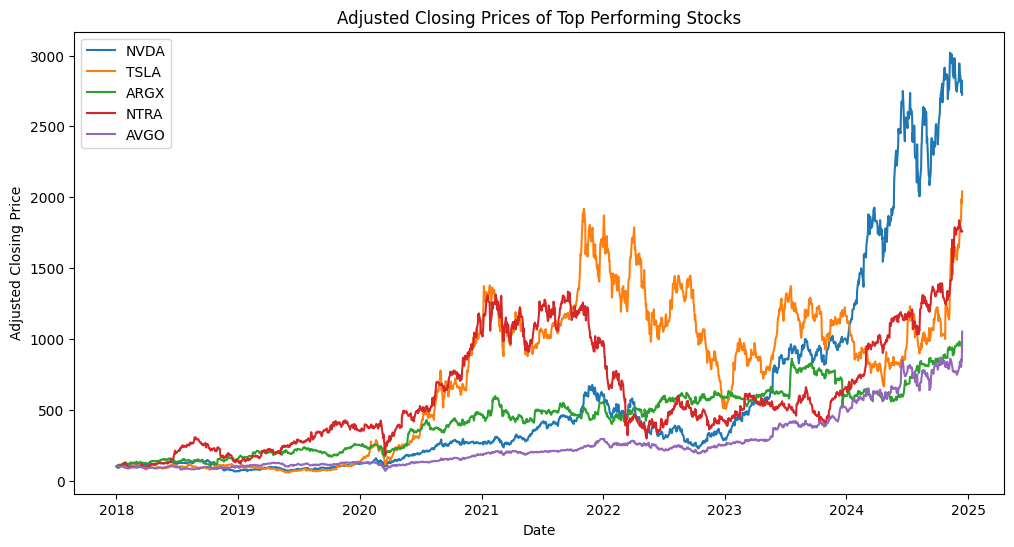

In [631]:
# Creating a line plot to show normalized adjusted closing prices for highest ror stocks
plt.figure(figsize=(12, 6))
plt.plot(filtered_final['date'], filtered_final['NVDA'], label='NVDA')
plt.plot(filtered_final['date'], filtered_final['TSLA'], label='TSLA')
plt.plot(filtered_final['date'], filtered_final['ARGX'], label='ARGX')
plt.plot(filtered_final['date'], filtered_final['NTRA'], label='NTRA')
plt.plot(filtered_final['date'], filtered_final['AVGO'], label='AVGO')
plt.xlabel('Date')
plt.ylabel('Adjusted Closing Price')
plt.title('Adjusted Closing Prices of Top Performing Stocks')
plt.legend()
plt.show()

Normalizing the top 5 stocks, we see consistent patterns in growth. Nvidia is an exceptional perfomer.

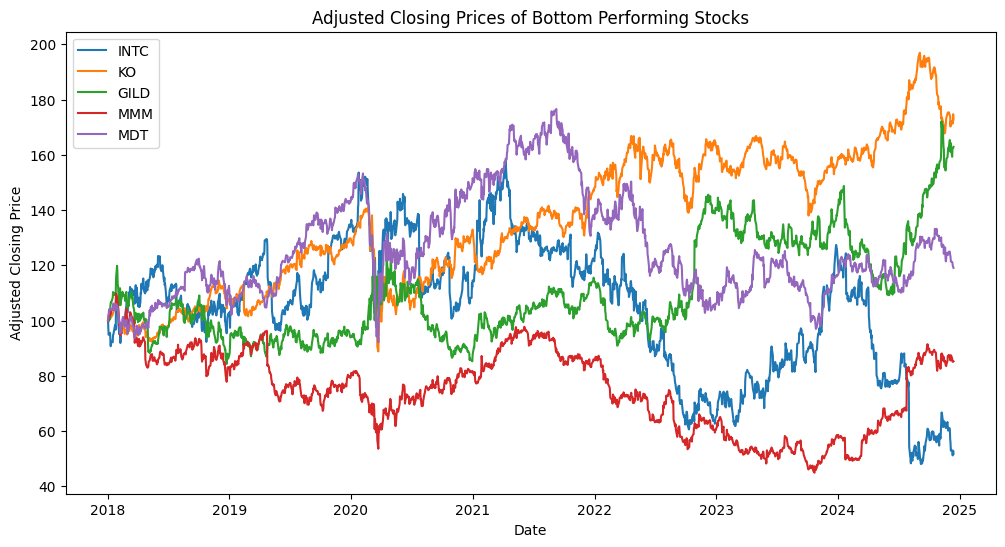

In [633]:
# Creating a line plot to show normalized adjusted closing prices for lowest ror stocks
plt.figure(figsize=(12, 6))
plt.plot(filtered_final['date'], filtered_final['INTC'], label='INTC')
plt.plot(filtered_final['date'], filtered_final['KO'], label='KO')
plt.plot(filtered_final['date'], filtered_final['GILD'], label='GILD')
plt.plot(filtered_final['date'], filtered_final['MMM'], label='MMM')
plt.plot(filtered_final['date'], filtered_final['MDT'], label='MDT')
plt.xlabel('Date')
plt.ylabel('Adjusted Closing Price')
plt.title('Adjusted Closing Prices of Bottom Performing Stocks')
plt.legend()
plt.show()

Normalizing the bottom 5 stocks, we see high volatility in their stock prices. INTC is the worst performer. Overall, all of these stocks are in the Healthcare sector except from INTC which is a Tech stock.